In [1]:
import pandas as pd
import os
import json

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

### Get ensembl gene mapping

In [4]:
with open('/cellar/users/mpagadal/resources/tcga/ensembl_map.json', 'r') as f:
    ensembl_dict = json.load(f)
ensembl_dict={k.split(".")[0]:v for k,v in ensembl_dict.items()}

## Get colocalization results

In [12]:
coloc_input="../cell-type-specificity/data/inputs/"
coloc_output="../cell-type-specificity/data/output/"

# collect collection of p value colocalization results

# files=[x for x in os.listdir(direct) if "p.summary.csv" in x]
# files=[x for x in files if "compiled" not in x]

# compiled=pd.DataFrame()

# for i,x in enumerate(files):
#     if i %100 ==0:
#         print("{}/{} files compiled".format(i,len(files)))
#     df=pd.read_csv(direct+x,index_col=0)
#     df=df.T
#     df["file"]=x
#     compiled=compiled.append(df)

# compiled.to_csv("coloc.results.csv")

## Get significant results

In [13]:
compiled=pd.read_csv("../data/coloc/coloc.results.csv",index_col=0)
compiled_sig=compiled[compiled["PP.H4.abf"]>0.8]

total_p_results=[]
total_p_sum=[]

for gene in compiled_sig["gene"].unique():
    files=([x for x in os.listdir(direct) if gene in x])
    p_results_files=[x for x in files if "p.results" in x]
    p_summary_files=[x for x in files if "p.summary" in x]
    
    total_p_results=total_p_results+p_results_files
    total_p_sum=total_p_sum+p_summary_files

compiled_p_sum=pd.DataFrame()

for i,x in enumerate(total_p_sum):
    if i %100 ==0:
        print(i)
    df=pd.read_csv(coloc_output+x,index_col=0)
    df=df.T
    df["file"]=x
    compiled_p_sum=compiled_p_sum.append(df)
    
compiled_p_sum["cell"]=compiled_p_sum["file"].str.split(".").str[0]
compiled_p_sum["gene"]=compiled_p_sum["file"].str.split(".").str[1]
compiled_p_sum["gene name"]=compiled_p_sum["gene"].map(ensembl_dict)

combo=[]
beta=[]

for i,x in enumerate(total_p_results):
    if i %100 ==0:
        print(i)
    file=x.split(".p.results.csv")[0]
    df=pd.read_csv(coloc_input+file+".csv")
    df=df.sort_values(by="P_mvp")
    df=df.reset_index()
    combo.append(file)
    if df.loc[0]["BETA_mvp"] > 0:
        beta.append(df.loc[0]["BETA_gtex"])
    else:
        beta.append(-1*df.loc[0]["BETA_gtex"])

df_beta=pd.DataFrame({"combo":combo,"beta":beta})
df_beta["cell"]=df_beta["combo"].str.split(".").str[0]
df_beta["gene"]=df_beta["combo"].str.split(".").str[1]
compiled_p_sum=pd.merge(compiled_p_sum,df_beta,on=["cell","gene"],how="left")


sorter=["Brain_Caudate_basal_ganglia",
        "Brain_Cerebellar_Hemisphere",
        "Brain_Hypothalamus",
        "Brain_Amygdala",
        "Brain_Frontal_Cortex_BA9",
        "Brain_Spinal_cord_cervical_c-1",
        "Brain_Substantia_nigra",
        "Brain_Hippocampus",
        "Brain_Cortex",
        "Brain_Cerebellum",
        "Brain_Putamen_basal_ganglia",
        "Brain_Anterior_cingulate_cortex_BA24",
        "Brain_Nucleus_accumbens_basal_ganglia",
        "Nerve_Tibial",
        "Pituitary",
        "Thyroid",
        "Adrenal_Gland",
        "Prostate",
        "Testis",
        "Ovary",
        "Vagina",
        "Uterus",
        "Skin_Sun_Exposed_Lower_leg",
        "Skin_Not_Sun_Exposed_Suprapubic",
        "Breast_Mammary_Tissue",
        "Adipose_Subcutaneous",
        "Adipose_Visceral_Omentum",
        "Whole_Blood",
        "Cells_Cultured_fibroblasts",
        "Cells_EBV-transformed_lymphocytes",
        "Spleen",
        "Liver",
        "Kidney_Cortex",
        "Minor_Salivary_Gland",
        "Esophagus_Mucosa",
        "Esophagus_Gastroesophageal_Junction",
        "Colon_Sigmoid",
        "Pancreas",
        "Small_Intestine_Terminal_Ileum",
        "Stomach",
        "Esophagus_Muscularis",
        "Colon_Transverse",
        "Lung",
        "Heart_Atrial_Appendage",
        "Heart_Left_Ventricle",
        "Muscle_Skeletal",
        "Artery_Aorta",
        "Artery_Coronary",
        "Artery_Tibial"]
sorterIndex = dict(zip(sorter, range(len(sorter))))
compiled_p_sum["index"]=compiled_p_sum["cell"].map(sorterIndex)
compiled_p_sum=compiled_p_sum.sort_values(by="index")

#overlap twas results
twas=pd.read_csv("../data/twas/mvp.testosterone.results.csv")
twas["association"]=twas["ID"]+twas["PANEL"]
coloc_sig=compiled_p_sum[compiled_p_sum["PP.H4.abf"]>0.8]
coloc_sig["association"]=coloc_sig["gene name"]+coloc_sig["cell"]
sig=coloc_sig[coloc_sig["association"].isin(twas["association"].tolist())]


0
100
200
300
400
500
600
700
800
900
1000
1100
1200
0


FileNotFoundError: [Errno 2] File b'../cell-type-specificity/data/inputs/Esophagus_Gastroesophageal_Junction.ENSG00000090621.csv' does not exist: b'../cell-type-specificity/data/inputs/Esophagus_Gastroesophageal_Junction.ENSG00000090621.csv'

{'Brain_Caudate_basal_ganglia': 0, 'Brain_Cerebellar_Hemisphere': 1, 'Brain_Hypothalamus': 2, 'Brain_Amygdala': 3, 'Brain_Frontal_Cortex_BA9': 4, 'Brain_Spinal_cord_cervical_c-1': 5, 'Brain_Substantia_nigra': 6, 'Brain_Hippocampus': 7, 'Brain_Cortex': 8, 'Brain_Cerebellum': 9, 'Brain_Putamen_basal_ganglia': 10, 'Brain_Anterior_cingulate_cortex_BA24': 11, 'Brain_Nucleus_accumbens_basal_ganglia': 12, 'Nerve_Tibial': 13, 'Pituitary': 14, 'Thyroid': 15, 'Adrenal_Gland': 16, 'Prostate': 17, 'Testis': 18, 'Ovary': 19, 'Vagina': 20, 'Uterus': 21, 'Skin_Sun_Exposed_Lower_leg': 22, 'Skin_Not_Sun_Exposed_Suprapubic': 23, 'Breast_Mammary_Tissue': 24, 'Adipose_Subcutaneous': 25, 'Adipose_Visceral_Omentum': 26, 'Whole_Blood': 27, 'Cells_Cultured_fibroblasts': 28, 'Cells_EBV-transformed_lymphocytes': 29, 'Spleen': 30, 'Liver': 31, 'Kidney_Cortex': 32, 'Minor_Salivary_Gland': 33, 'Esophagus_Mucosa': 34, 'Esophagus_Gastroesophageal_Junction': 35, 'Colon_Sigmoid': 36, 'Pancreas': 37, 'Small_Intestine_T

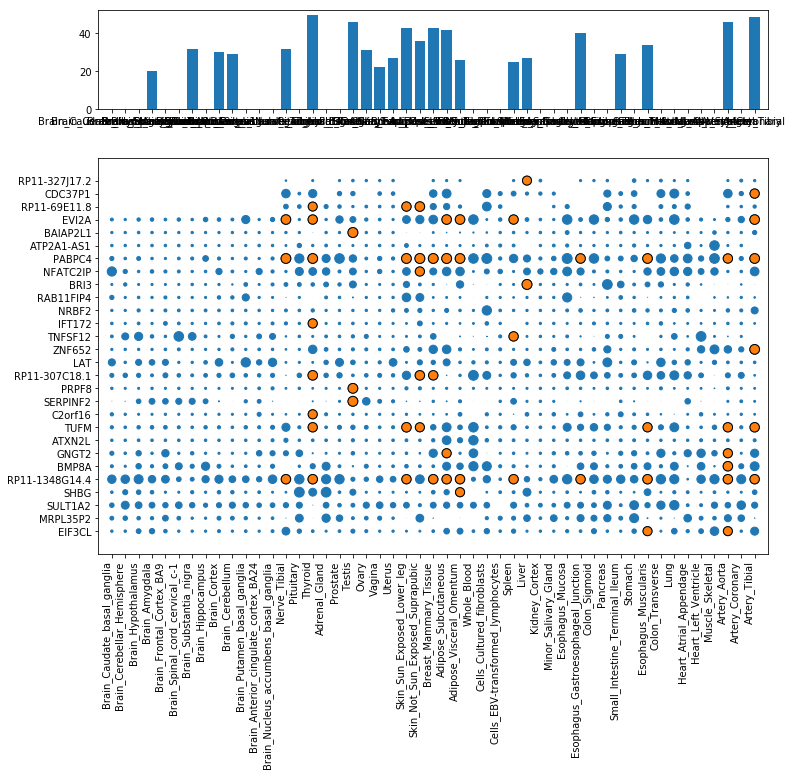

In [25]:
#Plot

def heatmap(x, y, size):
    fig, (ax, ax2) = plt.subplots(2,figsize=(12, 10), gridspec_kw={'height_ratios': [1, 4]})
    
    bar=twas[twas["TWAS.P"]<.000001]["PANEL"].value_counts().reset_index()
    dict_bar=dict(zip(bar["index"],bar["PANEL"]))
    df_bar=pd.DataFrame({"tissue":sorter})
    df_bar["num"]=df_bar["tissue"].map(dict_bar)
    df_bar["num"]=df_bar["num"].fillna(0)
    ax.bar(df_bar["tissue"],df_bar["num"])
    
    # Mapping from column names to integer coordinates
    x_labels = [v for v in x.unique()]
    y_labels = [v for v in y.unique()]
    x_to_num = {p[1]:p[0] for p in enumerate(x_labels)} 
    y_to_num = {p[1]:p[0] for p in enumerate(y_labels)} 
    
    print(x_to_num)
    size_scale = 100
    ax2.scatter(
        x=x.map(x_to_num), # Use mapping for x
        y=y.map(y_to_num), # Use mapping for y
        s=size * size_scale# Vector of square sizes, proportional to size parameter
    )
    
    ax2.scatter(
        x=sig["cell"].map(x_to_num), # Use mapping for x
        y=sig["gene name"].map(y_to_num), # Use mapping for y
        s=sig['PP.H4.abf'] * size_scale, 
        edgecolors="k"# Vector of square sizes, proportional to size parameter
    )
    
    # Show column labels on the axes
    ax2.set_xticks([x_to_num[v] for v in x_labels])
    ax2.set_xticklabels(x_labels, rotation=45, horizontalalignment='right')
    ax2.set_yticks([y_to_num[v] for v in y_labels])
    ax2.set_yticklabels(y_labels)
#     ax2.colorbar()
    
    plt.xticks(rotation=90)
    plt.xlim([-1,len(x_labels)])
    ax.set_xlim([-1,len(x_labels)])
    
heatmap(
    x=compiled_p_sum['cell'],
    y=compiled_p_sum['gene name'],
    size=compiled_p_sum['PP.H4.abf']
)

plt.savefig("coloc.pdf")

### make legend for points

In [122]:
df_size=compiled_p_sum.copy()

In [123]:
df_size["PP.H4.abf"]=np.where(df_size["cell"]=="Brain_Caudate_basal_ganglia",1,df_size["PP.H4.abf"])
df_size["PP.H4.abf"]=np.where(df_size["cell"]=="Brain_Cerebellar_Hemisphere",0.8,df_size["PP.H4.abf"])
df_size["PP.H4.abf"]=np.where(df_size["cell"]=="Brain_Hypothalamus",0.6,df_size["PP.H4.abf"])
df_size["PP.H4.abf"]=np.where(df_size["cell"]=="Brain_Amygdala",0.4,df_size["PP.H4.abf"])
df_size["PP.H4.abf"]=np.where(df_size["cell"]=="Brain_Frontal_Cortex_BA9",0.2,df_size["PP.H4.abf"])

{'Brain_Caudate_basal_ganglia': 0, 'Brain_Cerebellar_Hemisphere': 1, 'Brain_Hypothalamus': 2, 'Brain_Amygdala': 3, 'Brain_Frontal_Cortex_BA9': 4, 'Brain_Spinal_cord_cervical_c-1': 5, 'Brain_Substantia_nigra': 6, 'Brain_Hippocampus': 7, 'Brain_Cortex': 8, 'Brain_Cerebellum': 9, 'Brain_Putamen_basal_ganglia': 10, 'Brain_Anterior_cingulate_cortex_BA24': 11, 'Brain_Nucleus_accumbens_basal_ganglia': 12, 'Nerve_Tibial': 13, 'Pituitary': 14, 'Thyroid': 15, 'Adrenal_Gland': 16, 'Prostate': 17, 'Testis': 18, 'Ovary': 19, 'Vagina': 20, 'Uterus': 21, 'Skin_Sun_Exposed_Lower_leg': 22, 'Skin_Not_Sun_Exposed_Suprapubic': 23, 'Breast_Mammary_Tissue': 24, 'Adipose_Subcutaneous': 25, 'Adipose_Visceral_Omentum': 26, 'Whole_Blood': 27, 'Cells_Cultured_fibroblasts': 28, 'Cells_EBV-transformed_lymphocytes': 29, 'Spleen': 30, 'Liver': 31, 'Kidney_Cortex': 32, 'Minor_Salivary_Gland': 33, 'Esophagus_Mucosa': 34, 'Esophagus_Gastroesophageal_Junction': 35, 'Colon_Sigmoid': 36, 'Pancreas': 37, 'Small_Intestine_T

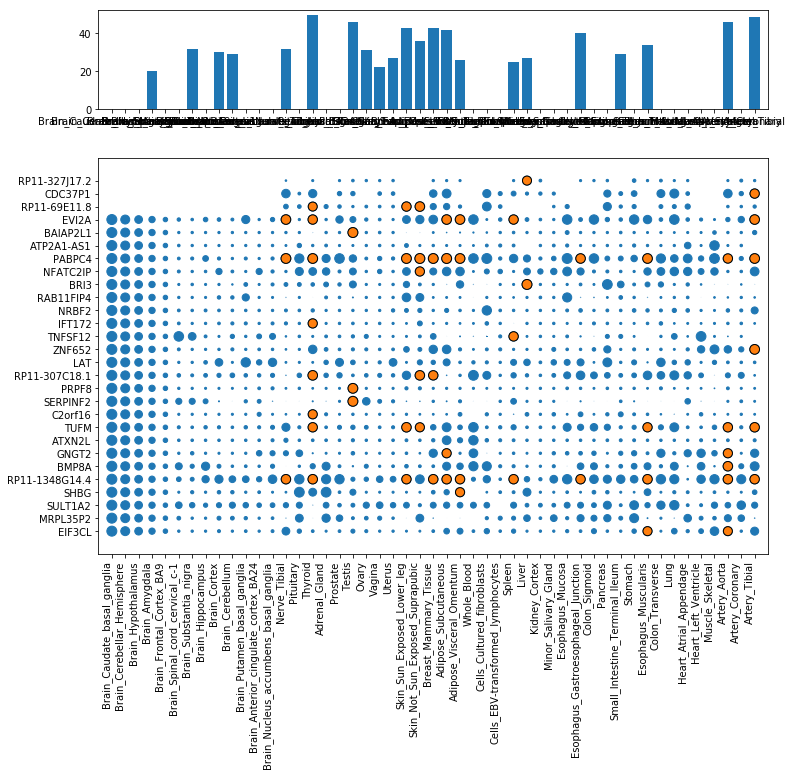

In [125]:
#Plot

def heatmap(x, y, size):
    fig, (ax, ax2) = plt.subplots(2,figsize=(12, 10), gridspec_kw={'height_ratios': [1, 4]})
    
    bar=twas[twas["TWAS.P"]<.000001]["PANEL"].value_counts().reset_index()
    dict_bar=dict(zip(bar["index"],bar["PANEL"]))
    df_bar=pd.DataFrame({"tissue":sorter})
    df_bar["num"]=df_bar["tissue"].map(dict_bar)
    df_bar["num"]=df_bar["num"].fillna(0)
    ax.bar(df_bar["tissue"],df_bar["num"])
    
    # Mapping from column names to integer coordinates
    x_labels = [v for v in x.unique()]
    y_labels = [v for v in y.unique()]
    x_to_num = {p[1]:p[0] for p in enumerate(x_labels)} 
    y_to_num = {p[1]:p[0] for p in enumerate(y_labels)} 
    
    print(x_to_num)
    size_scale = 100
    ax2.scatter(
        x=x.map(x_to_num), # Use mapping for x
        y=y.map(y_to_num), # Use mapping for y
        s=size * size_scale# Vector of square sizes, proportional to size parameter
    )
    
    ax2.scatter(
        x=sig["cell"].map(x_to_num), # Use mapping for x
        y=sig["gene name"].map(y_to_num), # Use mapping for y
        s=sig['PP.H4.abf'] * size_scale, 
        edgecolors="k"# Vector of square sizes, proportional to size parameter
    )
    
    # Show column labels on the axes
    ax2.set_xticks([x_to_num[v] for v in x_labels])
    ax2.set_xticklabels(x_labels, rotation=45, horizontalalignment='right')
    ax2.set_yticks([y_to_num[v] for v in y_labels])
    ax2.set_yticklabels(y_labels)
#     ax2.colorbar()
    
    plt.xticks(rotation=90)
    plt.xlim([-1,len(x_labels)])
    ax.set_xlim([-1,len(x_labels)])
    
heatmap(
    x=df_size['cell'],
    y=df_size['gene name'],
    size=df_size['PP.H4.abf']
)

plt.savefig("coloc.size.pdf")